In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import json

In [2]:
data_dir = 'datasets/EuroSAT_RGB/'
label_names = sorted(os.listdir(data_dir))
label_names.remove('.DS_Store')
label_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [3]:
# count number of images per class
class_counts = {label: len(os.listdir(os.path.join(data_dir, label))) for label in label_names}
class_counts

{'AnnualCrop': 3000,
 'Forest': 3000,
 'HerbaceousVegetation': 3000,
 'Highway': 2500,
 'Industrial': 2500,
 'Pasture': 2000,
 'PermanentCrop': 2500,
 'Residential': 3000,
 'River': 2500,
 'SeaLake': 3000}

## visualize R, G, B

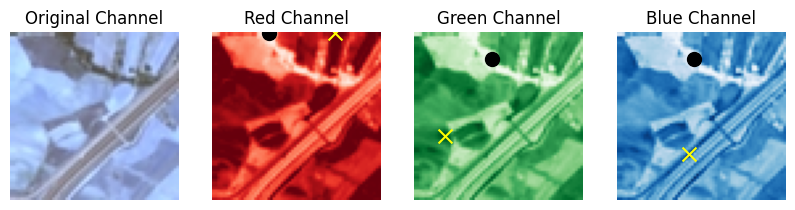

In [4]:
label = label_names[3]
path = os.path.join(data_dir, label, os.listdir(os.path.join(data_dir, label))[0])

img = cv2.imread(path)
B, G, R = cv2.split(img)
titles = ["Original", "Red", "Green", "Blue"]
cmaps = [None, "Reds", "Greens", "Blues"]

# plot the RGB channels
plt.figure(figsize=(10, 6))
for img, color, i in zip([img, R, G, B], ['Original', 'Red', 'Green', 'Blue'], range(4)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap=cmaps[i])
    if color != 'Original':
        max_idx = np.unravel_index(np.argmax(img), img.shape)
        min_idx = np.unravel_index(np.argmin(img), img.shape)
        plt.scatter(max_idx[1], max_idx[0], color='yellow', marker='x', s=100)
        plt.scatter(min_idx[1], min_idx[0], color='black', marker='o', s=100)
    plt.title(f'{color} Channel')
    plt.axis('off')

In [5]:
patch_size = 32
img_quadrants = []
for channel in [R, G, B]:
    for i in range(0, channel.shape[0], patch_size):
        for j in range(0, channel.shape[1], patch_size):
            quadrant = channel[i:i+patch_size, j:j+patch_size]
            img_quadrants.append(quadrant)

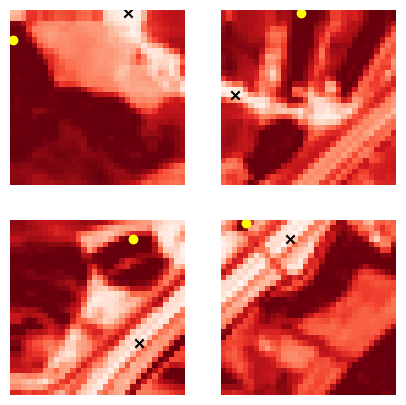

In [6]:
# plot red channel quadrants
plt.figure(figsize=(5, 5))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img_quadrants[i], cmap='Reds')
    # plot max and min pixel values
    # get idx of max and min pixel values
    max_idx = np.unravel_index(np.argmax(img_quadrants[i]), img_quadrants[i].shape)
    min_idx = np.unravel_index(np.argmin(img_quadrants[i]), img_quadrants[i].shape)
    # plot max and min pixel values
    plt.scatter(max_idx[1], max_idx[0], color='yellow', marker='o', label='Max')
    plt.scatter(min_idx[1], min_idx[0], color='black', marker='x', label='Min')
    plt.axis('off')

### feature engineering

In [7]:
def divide_into_quadrants(image, patch_size=32):
    quadrants = []
    for i in range(0, image.shape[0], patch_size):
        for j in range(0, image.shape[1], patch_size):
            quadrant = image[i:i+patch_size, j:j+patch_size]
            quadrants.append(quadrant)
    return quadrants

In [8]:
def compute_stats(path_label):
    path, label = path_label
    img = cv2.imread(path)
    if img is None:
        return None  # skip bad images
    stats = {}
    for i, color in enumerate(['Blue', 'Green', 'Red']):
        channel = img[:, :, i]
        stats[f'{color}_mean'] = channel.mean()
        stats[f'{color}_std'] = channel.std()
        stats[f'{color}_min'] = channel.min()
        stats[f'{color}_max'] = channel.max()

        quadrants = divide_into_quadrants(channel)
        for j, quadrant in enumerate(quadrants):
            stats[f'{color}_quadrant_{j}_mean'] = quadrant.mean()
            stats[f'{color}_quadrant_{j}_std'] = quadrant.std()
            stats[f'{color}_quadrant_{j}_min'] = quadrant.min()
            stats[f'{color}_quadrant_{j}_max'] = quadrant.max()
    
    img_num = os.path.basename(path).split("_")[1].split('.')[0]

    return {
        'image_id': img_num,
        'label': label,
        **stats
    }

In [9]:
# Build list of (path, label)
paths = [
    (os.path.join(data_dir, label, fname), label)
    for label in label_names
    for fname in os.listdir(os.path.join(data_dir, label))
]

# Apply map
data_stats = list(filter(None, map(compute_stats, paths)))

In [10]:
df = pd.DataFrame(data_stats)
df.set_index('image_id', inplace=True)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Blue_quadrant_0_mean,Blue_quadrant_0_std,Blue_quadrant_0_min,Blue_quadrant_0_max,Blue_quadrant_1_mean,...,Red_quadrant_1_min,Red_quadrant_1_max,Red_quadrant_2_mean,Red_quadrant_2_std,Red_quadrant_2_min,Red_quadrant_2_max,Red_quadrant_3_mean,Red_quadrant_3_std,Red_quadrant_3_min,Red_quadrant_3_max
image_id,,,,,,,,,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,122.563477,17.302171,92,160,106.021484,...,57,159,100.156250,40.835357,57,176,160.511719,27.698817,62,207
1372,AnnualCrop,110.764893,22.730603,76,199,116.260742,25.495009,76,199,118.134766,...,58,225,99.659180,35.840059,47,172,103.274414,40.767561,48,221
1366,AnnualCrop,126.442627,22.481973,82,180,121.389648,20.013997,93,165,145.422852,...,105,255,114.382812,24.414230,69,171,185.630859,59.808830,105,255
2109,AnnualCrop,138.062256,26.238712,81,214,144.258789,27.933487,87,214,134.570312,...,81,255,159.750000,43.857858,55,232,170.340820,49.860822,76,255
1400,AnnualCrop,127.583740,16.045508,70,162,124.145508,16.339337,73,162,129.523438,...,63,235,165.315430,37.435819,57,234,180.625000,22.098324,108,233


In [14]:
map_labels2idx = {label: idx for idx, label in enumerate(label_names)}
map_idx2labels = {idx: label for label, idx in map_labels2idx.items()}

with open("feature_store/v1/map_labels2idx.json", "w") as f:
    json.dump(map_labels2idx, f)

with open("feature_store/v1/map_idx2labels.json", "w") as f:
    json.dump(map_idx2labels, f)

In [15]:
df["label_idx"] = df["label"].map(map_labels2idx)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Blue_quadrant_0_mean,Blue_quadrant_0_std,Blue_quadrant_0_min,Blue_quadrant_0_max,Blue_quadrant_1_mean,...,Red_quadrant_1_max,Red_quadrant_2_mean,Red_quadrant_2_std,Red_quadrant_2_min,Red_quadrant_2_max,Red_quadrant_3_mean,Red_quadrant_3_std,Red_quadrant_3_min,Red_quadrant_3_max,label_idx
image_id,,,,,,,,,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,122.563477,17.302171,92,160,106.021484,...,159,100.156250,40.835357,57,176,160.511719,27.698817,62,207,0
1372,AnnualCrop,110.764893,22.730603,76,199,116.260742,25.495009,76,199,118.134766,...,225,99.659180,35.840059,47,172,103.274414,40.767561,48,221,0
1366,AnnualCrop,126.442627,22.481973,82,180,121.389648,20.013997,93,165,145.422852,...,255,114.382812,24.414230,69,171,185.630859,59.808830,105,255,0
2109,AnnualCrop,138.062256,26.238712,81,214,144.258789,27.933487,87,214,134.570312,...,255,159.750000,43.857858,55,232,170.340820,49.860822,76,255,0
1400,AnnualCrop,127.583740,16.045508,70,162,124.145508,16.339337,73,162,129.523438,...,235,165.315430,37.435819,57,234,180.625000,22.098324,108,233,0


In [16]:
# Prepare data for stratified split
X = df[df.columns.difference(['label','label_idx'])].values
y = df['label_idx'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
PATH_FEATURE_STORE = 'feature_store/v1/'
os.makedirs(PATH_FEATURE_STORE, exist_ok=True)

# Save train and test sets as CSV files
train_df = pd.DataFrame(X_train, columns=df.columns.difference(['label','label_idx']))
train_df['label_idx'] = y_train
train_df.to_csv(PATH_FEATURE_STORE + 'train_data.csv', index=False)

test_df = pd.DataFrame(X_test, columns=df.columns.difference(['label','label_idx']))
test_df['label_idx'] = y_test
test_df.to_csv(PATH_FEATURE_STORE + 'test_data.csv', index=False)

In [18]:
# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3]
}

hyp_param_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=2,  # stratified 5-fold cross-validation
    random_state=42,
    n_jobs=-1
)

hyp_param_search.fit(X_train, y_train)
print("Best Hyperparameters:", hyp_param_search.best_params_)
print("Best CV Score:", hyp_param_search.best_score_)

/opt/homebrew/Caskroom/miniconda/base/envs/remote/lib/python3.10/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score: 0.7858796296296297


In [19]:
# Train final model with best hyperparameters
best_model = GradientBoostingClassifier(**hyp_param_search.best_params_, random_state=42)
best_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
PATH_REGISTRY = 'model_registry/v1/'
os.makedirs(PATH_REGISTRY, exist_ok=True)

# save model as pickle file
import joblib
joblib.dump(best_model, PATH_REGISTRY + 'best_model.pkl')

# save hyperparameters as json file
import json
# add seed
hyp_param_search.best_params_['random_state'] = 42
with open(PATH_REGISTRY + 'best_model_hyperparameters.json', 'w') as f:
    json.dump(hyp_param_search.best_params_, f)

In [42]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
report_results = classification_report(y_test, y_pred, target_names=label_names)
print(report_results)

                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.83      0.83       600
              Forest       0.91      0.94      0.92       600
HerbaceousVegetation       0.75      0.72      0.74       600
             Highway       0.56      0.44      0.49       500
          Industrial       0.87      0.92      0.89       500
             Pasture       0.76      0.82      0.79       400
       PermanentCrop       0.65      0.66      0.65       500
         Residential       0.80      0.86      0.83       600
               River       0.65      0.68      0.66       500
             SeaLake       0.97      0.95      0.96       600

            accuracy                           0.79      5400
           macro avg       0.78      0.78      0.78      5400
        weighted avg       0.78      0.79      0.78      5400



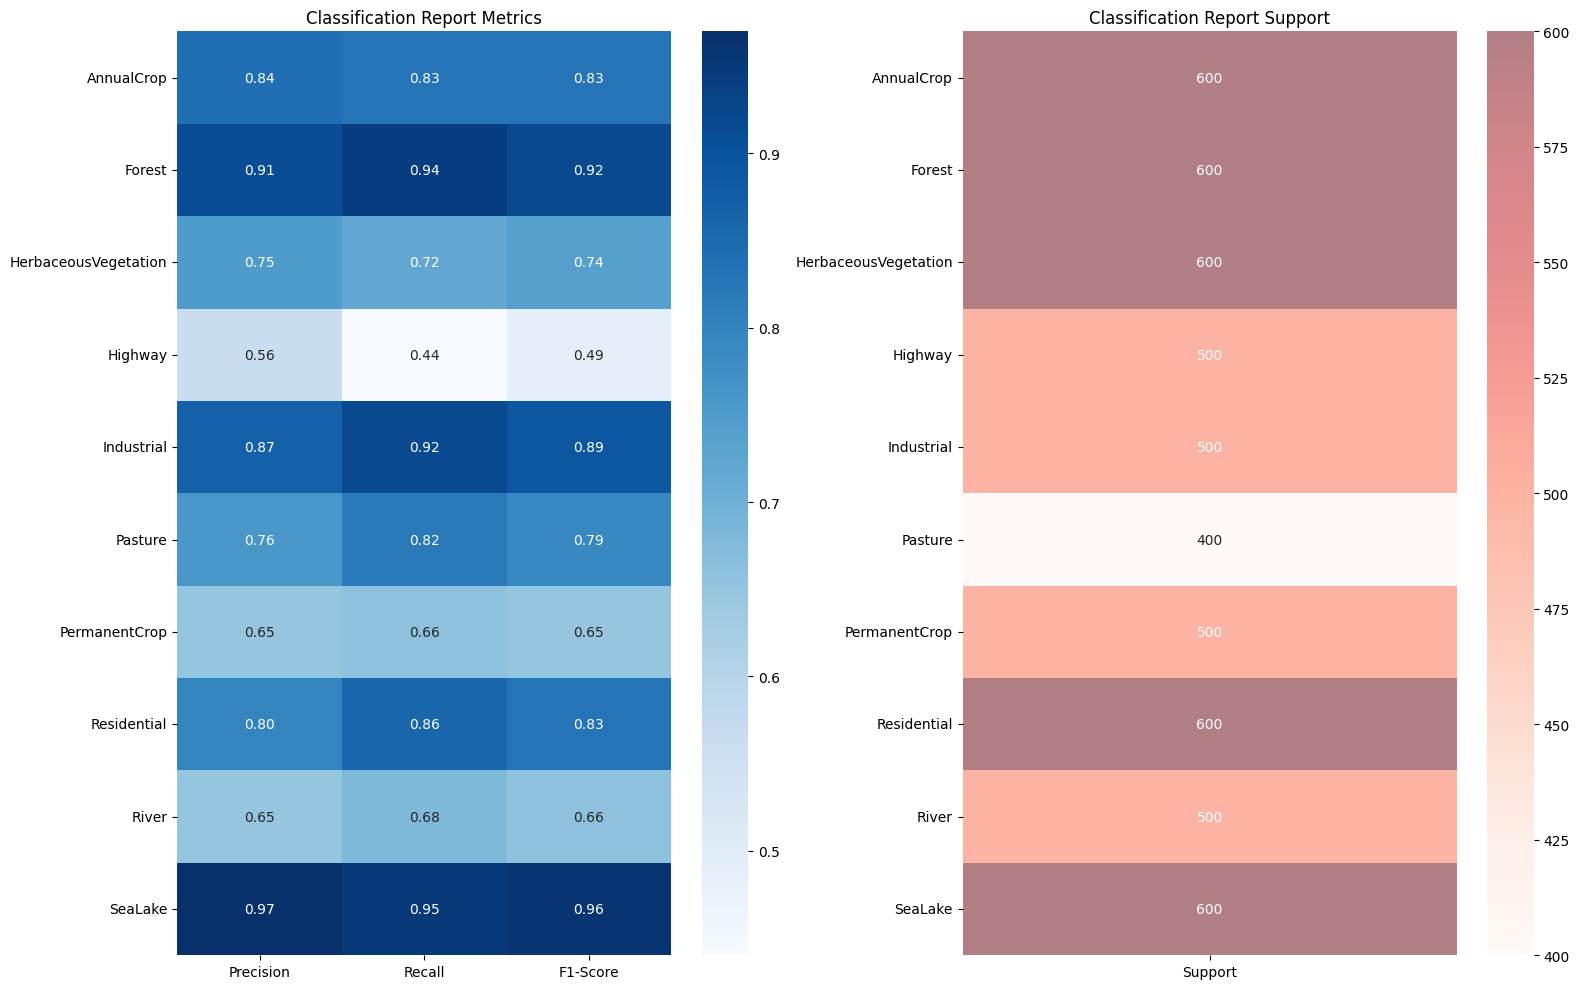

In [51]:

# classification report results as heatmap
report_results_matrix = report_results.splitlines()[2:-3]
report_results_matrix = [line.split() for line in report_results_matrix]

# get numbers from classification report results and convert to float
report_results_matrix_metrics = [[float(num) for num in line[1:-1]] for line in report_results_matrix][:-1]
# get support numbers from classification report results and convert to int
report_results_matrix_support = [[int(num) for num in line[-1:]] for line in report_results_matrix][:-1]

# create two heatmaps as subplots, one for precision, recall and f1-score, and one for support
fig, axs = plt.subplots(ncols=2, figsize=(16, 10))

sns.heatmap(report_results_matrix_metrics, annot=True, fmt=".2f", cmap="Blues", xticklabels=["Precision", "Recall", "F1-Score"], yticklabels=label_names, ax=axs[0])
axs[0].set_title("Classification Report Metrics")   
sns.heatmap(report_results_matrix_support, annot=True, fmt="d", cmap="Reds", xticklabels=["Support"], yticklabels=label_names, ax=axs[1], alpha=0.5)
axs[1].set_title("Classification Report Support")
plt.tight_layout()
plt.show()



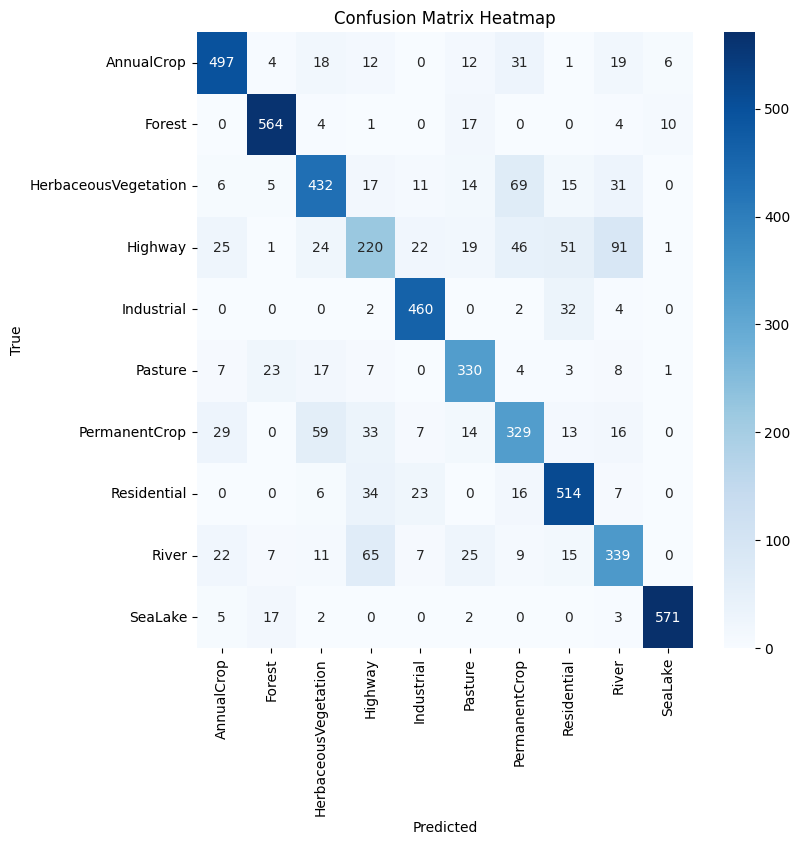

In [22]:
conf_mat_results = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_results, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

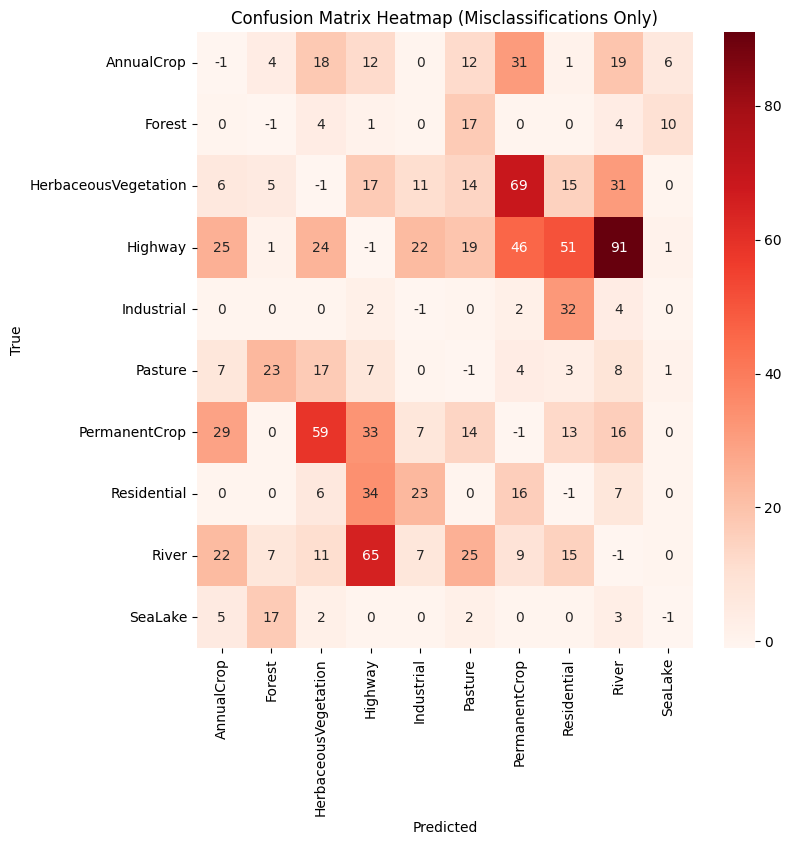

In [ ]:
mask = np.eye(conf_mat_results.shape[0], dtype=bool)
conf_mat_masked = np.where(mask, -1, conf_mat_results)

# plot masked confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_masked, annot=True, fmt='d', cmap='Reds', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap (Misclassifications Only)')
plt.show()

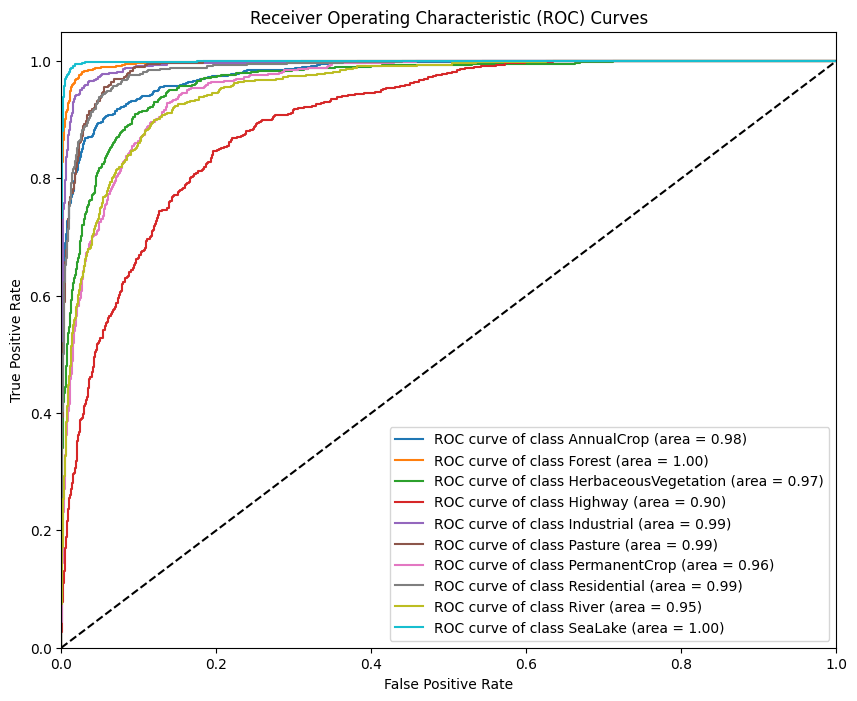

In [23]:
# add roc curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output
y_test_binarized = label_binarize(y_test, classes=range(len(label_names)))
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(label_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(len(label_names)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {label_names[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()